**You are the average of the five people you spend the most time with.    - Jim Rohn**

The Quote: Suggests that an individual is shaped by the influences of the people closest to them.

k-NN Algorithm: Determines the class or value of a data point based on the characteristics of its closest neighbors in the feature space.

In both cases, proximity to a group influences the outcome:

In the quote, proximity is in terms of relationships or time spent.

In k-NN, proximity is in terms of Euclidean distance (or another metric) in a feature space.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from collections import Counter


**Load Data**

In [2]:
# Load Data
df_original = pd.read_csv('Children Recode_final.csv')

# Drop unnecessary columns
df = df_original.drop(['Underweight', 'Wasting'], axis=1)

**Train-test Split**

In [4]:
# Feature and Target selection
X = df.drop(columns=['Stunting'])
y = df['Stunting']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


*Cross-validation for Best k-value*

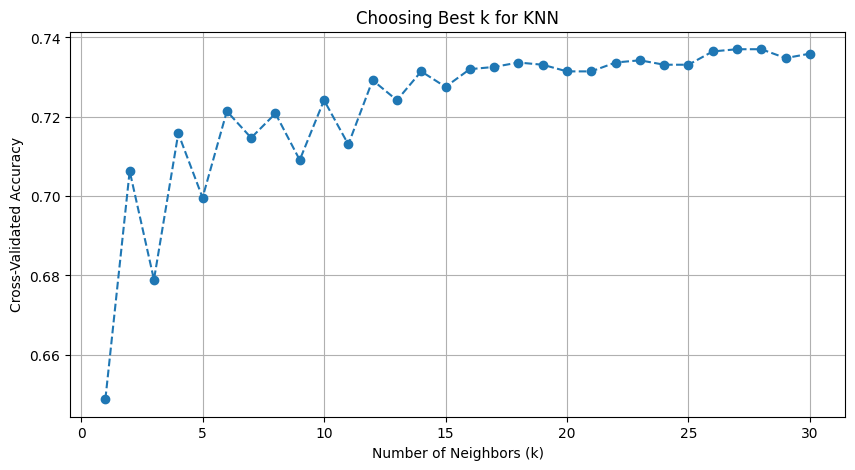

Best k: 27, Accuracy: 0.7370


In [5]:

# Finding the best k using cross-validation
k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')  
    cv_scores.append(scores.mean())

# Plot accuracy vs. k values
plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_scores, marker='o', linestyle='dashed')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Choosing Best k for KNN')
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(cv_scores)]
print(f"Best k: {best_k}, Accuracy: {max(cv_scores):.4f}")

Problem here is; it gives different values for k while we choose different values of cv. How to identify the best possible value for cv to optimize k. If we happed to assign cv = 19 then we will have k = 19 and it has higher accuracy. 

**Model Fit without Scaling and Balancing**

In [7]:


# KNN Model
knn = KNeighborsClassifier(n_neighbors=19)
knn.fit(X_train, y_train)

# Predictions & Accuracy
predictions = knn.predict(X_test)
accuracy = knn.score(X_test, y_test)

accuracy


0.7745535714285714

**Model's Performance**

In [8]:


# KNN Model
knn = KNeighborsClassifier(n_neighbors=19)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(accuracy_score(y_test, y_pred))
pd.crosstab(y_test, y_pred)

0.7745535714285714


col_0,0,1
Stunting,,
0,340,3
1,98,7


In [9]:
# Classification Report
print(classification_report(y_test, y_pred))

# ROC-AUC Score
auc = roc_auc_score(y_test, knn.predict_proba(X_test)[:,1])
print(f"ROC-AUC Score: {auc:.4f}")

              precision    recall  f1-score   support

           0       0.78      0.99      0.87       343
           1       0.70      0.07      0.12       105

    accuracy                           0.77       448
   macro avg       0.74      0.53      0.50       448
weighted avg       0.76      0.77      0.70       448

ROC-AUC Score: 0.5814


## Balancing using Synthetic Minority Oversampling Technique (SMOTE)

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train.astype('float'), y_train)

print("Before SMOTE: " , Counter(y_train))
print("After SMOTE:", Counter(y_train_smote))

Before SMOTE:  Counter({0: 1317, 1: 474})
After SMOTE: Counter({1: 1317, 0: 1317})


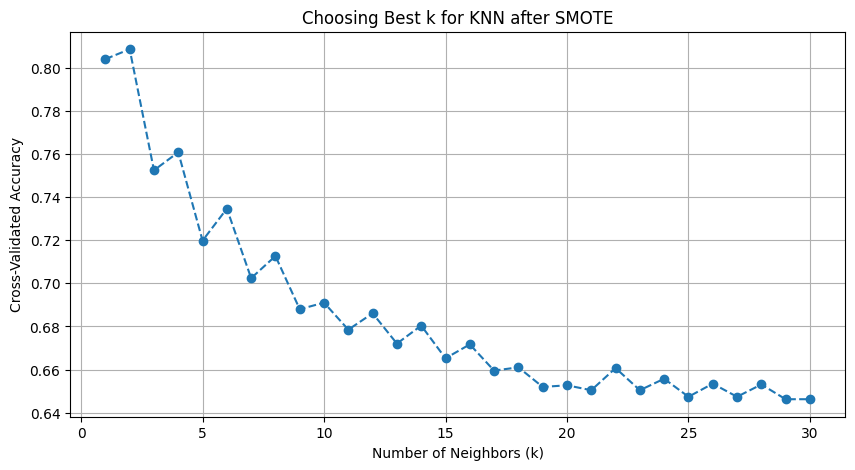

Best k after balancing: 2, Accuracy: 0.8087


In [11]:
k_values = range(1, 31)  
cv_scores = []

for k in k_values:
    knn_smote = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_smote, X_train_smote, y_train_smote, cv=10, scoring='accuracy')  
    cv_scores.append(scores.mean())

# Plot accuracy vs. k values
plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_scores, marker='o', linestyle='dashed')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Choosing Best k for KNN after SMOTE')
plt.grid(True)
plt.show()

# Best k selection
best_k = k_values[np.argmax(cv_scores)]
print(f"Best k after balancing: {best_k}, Accuracy: {max(cv_scores):.4f}")

In [12]:
# KNN Model
knn_smote = KNeighborsClassifier(n_neighbors=2)
knn_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = knn_smote.predict(X_test)

print(accuracy_score(y_test, y_pred_smote))
pd.crosstab(y_test, y_pred_smote)

0.6517857142857143


col_0,0,1
Stunting,,
0,266,77
1,79,26


In [13]:
# Classification Report
print(classification_report(y_test, y_pred_smote))

# ROC-AUC Score
auc = roc_auc_score(y_test, knn_smote.predict_proba(X_test)[:,1])
print(f"ROC-AUC Score: {auc:.4f}")


              precision    recall  f1-score   support

           0       0.77      0.78      0.77       343
           1       0.25      0.25      0.25       105

    accuracy                           0.65       448
   macro avg       0.51      0.51      0.51       448
weighted avg       0.65      0.65      0.65       448

ROC-AUC Score: 0.5289


## Model Fit with Scaling and Balancing